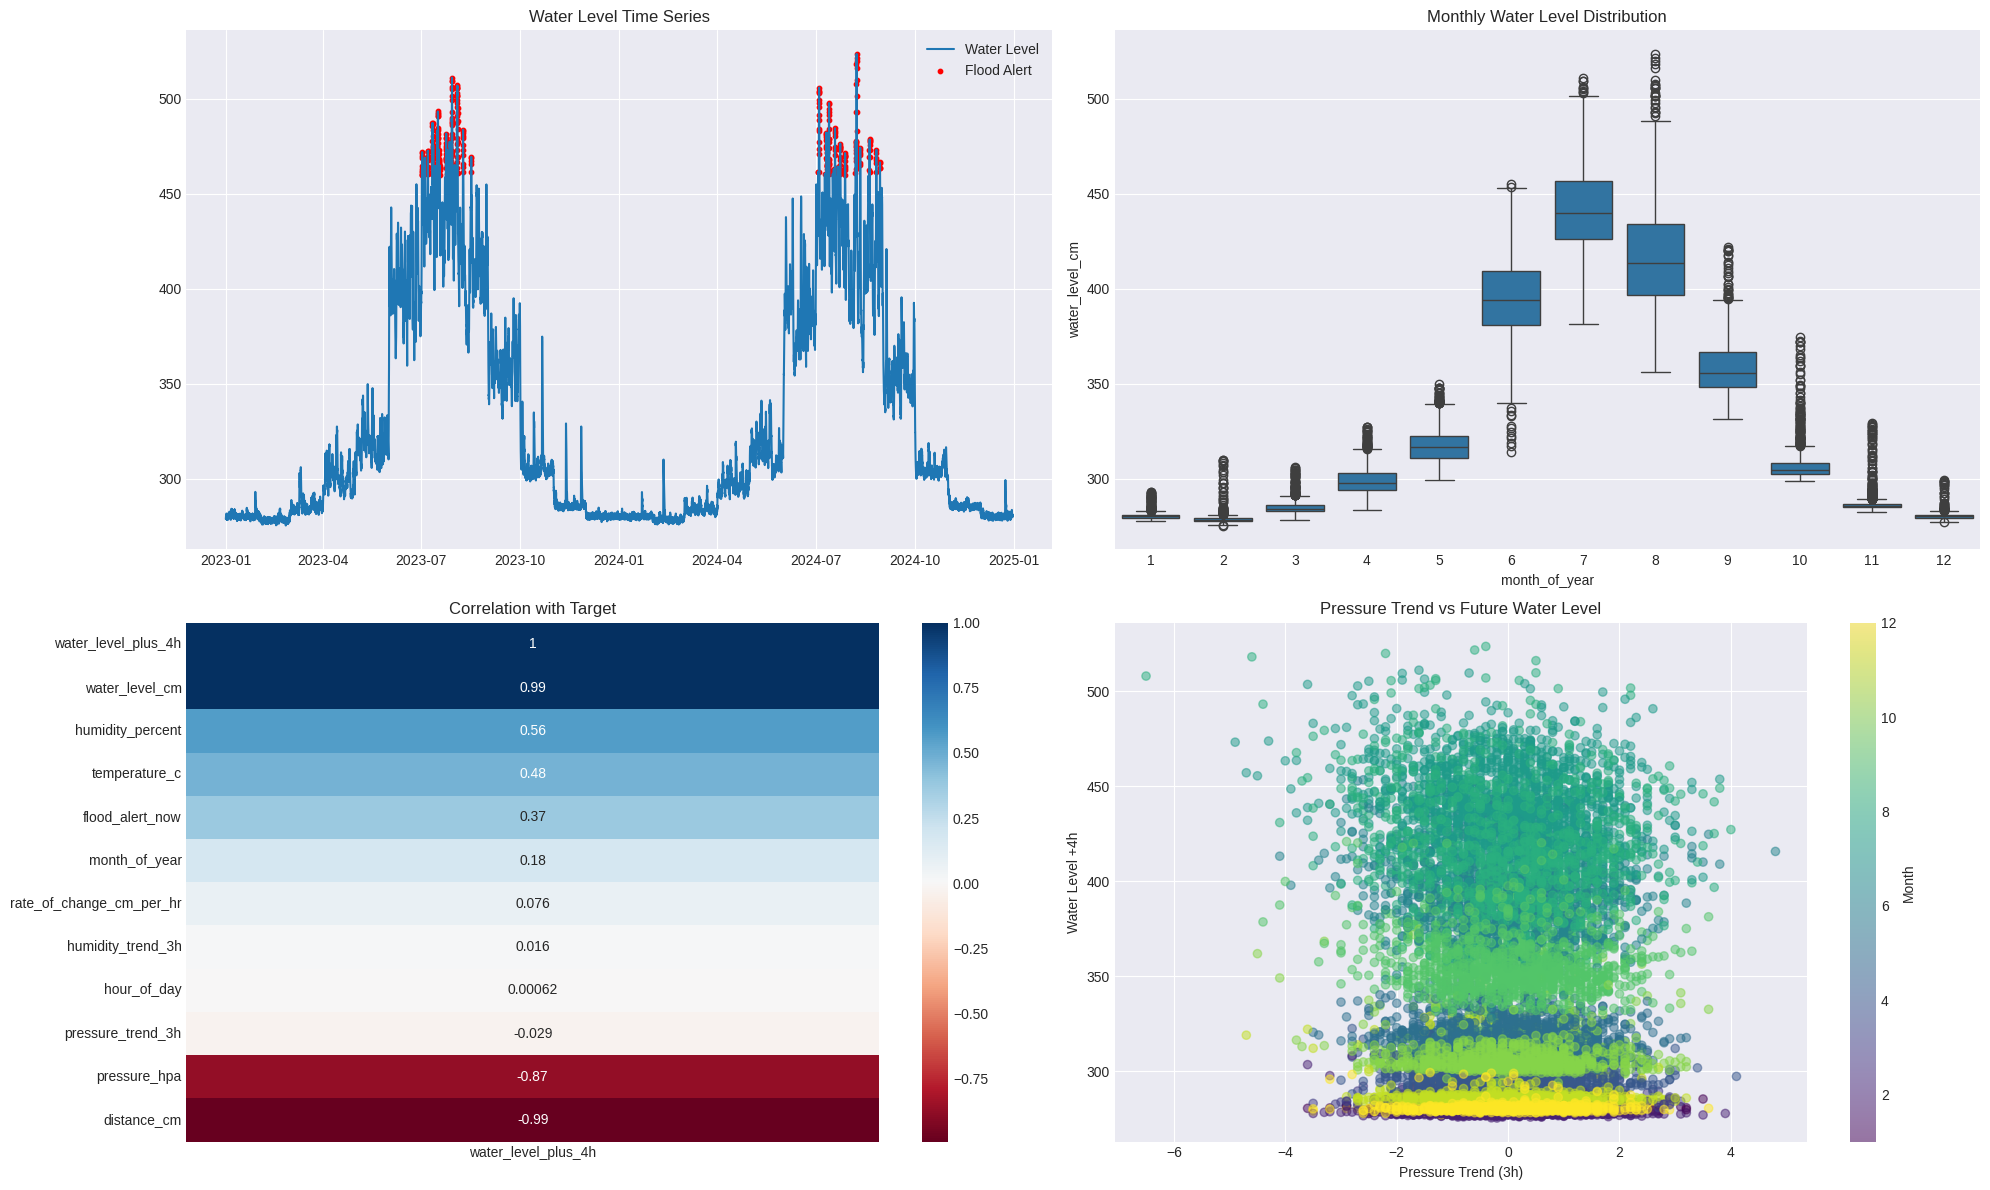

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# Configuration
CSV_PATH = 'assam_flood_sensor_data.csv'
LOOKBACK = 48
TARGET_COL = 'water_level_plus_4h'
DANGER_THRESHOLD = 450 # Example threshold in cm

# 1. Load and Setup
df_raw = pd.read_csv(CSV_PATH)
df_raw['datetime'] = pd.to_datetime(df_raw['date'] + ' ' + df_raw['time'])
df_raw = df_raw.sort_values('datetime').set_index('datetime')

# EDA Plots
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# Plot 1: Time Series
axes[0,0].plot(df_raw.index, df_raw['water_level_cm'], label='Water Level')
flood_periods = df_raw[df_raw['flood_alert_now'] == 1].index
axes[0,0].scatter(flood_periods, df_raw.loc[flood_periods, 'water_level_cm'], color='red', s=10, label='Flood Alert')
axes[0,0].set_title('Water Level Time Series')
axes[0,0].legend()

# Plot 2: Seasonality
sns.boxplot(data=df_raw, x='month_of_year', y='water_level_cm', ax=axes[0,1])
axes[0,1].set_title('Monthly Water Level Distribution')

# Plot 3: Correlation
corr = df_raw.select_dtypes(include=[np.number]).corr()[[TARGET_COL]].sort_values(by=TARGET_COL, ascending=False)
sns.heatmap(corr, annot=True, cmap='RdBu', ax=axes[1,0])
axes[1,0].set_title('Correlation with Target')

# Plot 4: Pressure Trend vs Target
scatter = axes[1,1].scatter(df_raw['pressure_trend_3h'], df_raw[TARGET_COL], c=df_raw['month_of_year'], cmap='viridis', alpha=0.5)
plt.colorbar(scatter, ax=axes[1,1], label='Month')
axes[1,1].set_xlabel('Pressure Trend (3h)')
axes[1,1].set_ylabel('Water Level +4h')
axes[1,1].set_title('Pressure Trend vs Future Water Level')

plt.tight_layout()
plt.savefig('eda_plots.png')
plt.show()

In [ ]:
# 2. Preprocessing
def prepare_sequences(df):
    # Cyclical Encoding
    df['hour_sin'] = np.sin(2 * np.pi * df['hour_of_day'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour_of_day'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month_of_year'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month_of_year'] / 12)

    features = ['hour_sin', 'hour_cos', 'month_sin', 'month_cos',
                'temperature_c', 'humidity_percent', 'pressure_hpa',
                'pressure_trend_3h', 'humidity_trend_3h', 'water_level_cm', 'rate_of_change_cm_per_hr']

    X_raw = df[features].values
    y_raw = df[TARGET_COL].values.reshape(-1, 1)

    # Chronological Split (70/15/15)
    n = len(df)
    train_idx = int(n * 0.7)
    val_idx = int(n * 0.85)

    # Scaling
    scaler_x = StandardScaler()
    scaler_y = StandardScaler()

    X_train_scaled = scaler_x.fit_transform(X_raw[:train_idx])
    X_val_scaled = scaler_x.transform(X_raw[train_idx:val_idx])
    X_test_scaled = scaler_x.transform(X_raw[val_idx:])

    y_train_scaled = scaler_y.fit_transform(y_raw[:train_idx])
    y_val_scaled = scaler_y.transform(y_raw[train_idx:val_idx])
    y_test_scaled = scaler_y.transform(y_raw[val_idx:])

    # Save scalers for JS
    scaler_params = {
        "x_mean": scaler_x.mean_.tolist(),
        "x_scale": scaler_x.scale_.tolist(),
        "y_mean": scaler_y.mean_[0],
        "y_scale": scaler_y.scale_[0],
        "feature_order": features
    }
    with open('scalers.json', 'w') as f:
        json.dump(scaler_params, f)

    def create_windows(X, y, window_size):
        X_win, y_win = [], []
        for i in range(window_size, len(X)):
            X_win.append(X[i-window_size:i])
            y_win.append(y[i])
        return np.array(X_win), np.array(y_win)

    X_train, y_train = create_windows(X_train_scaled, y_train_scaled, LOOKBACK)
    X_val, y_val = create_windows(X_val_scaled, y_val_scaled, LOOKBACK)
    X_test, y_test = create_windows(X_test_scaled, y_test_scaled, LOOKBACK)

    return X_train, y_train, X_val, y_val, X_test, y_test, scaler_y, df.iloc[val_idx+LOOKBACK:].copy()

X_train, y_train, X_val, y_val, X_test, y_test, scaler_y, test_df_with_dates = prepare_sequences(df_raw)

Epoch 1/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 0.0473 - mae: 0.1334 - val_loss: 0.0592 - val_mae: 0.1816 - learning_rate: 0.0010
Epoch 2/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0210 - mae: 0.0969 - val_loss: 0.0453 - val_mae: 0.1678 - learning_rate: 0.0010
Epoch 3/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0162 - mae: 0.0822 - val_loss: 0.0613 - val_mae: 0.1964 - learning_rate: 0.0010
Epoch 4/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0152 - mae: 0.0786 - val_loss: 0.0407 - val_mae: 0.1539 - learning_rate: 0.0010
Epoch 5/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0127 - mae: 0.0710 - val_loss: 0.0427 - val_mae: 0.1564 - learning_rate: 0.0010
Epoch 6/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0110 - mae: 0.0680 - val_loss: 0.0458 - val_mae: 0.1710 - learning_rate: 0.0010
Epoch 7/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0102 - mae: 0.0647 - val_loss: 0.0634 - val_mae: 0.2018 - learning_rate: 0.001

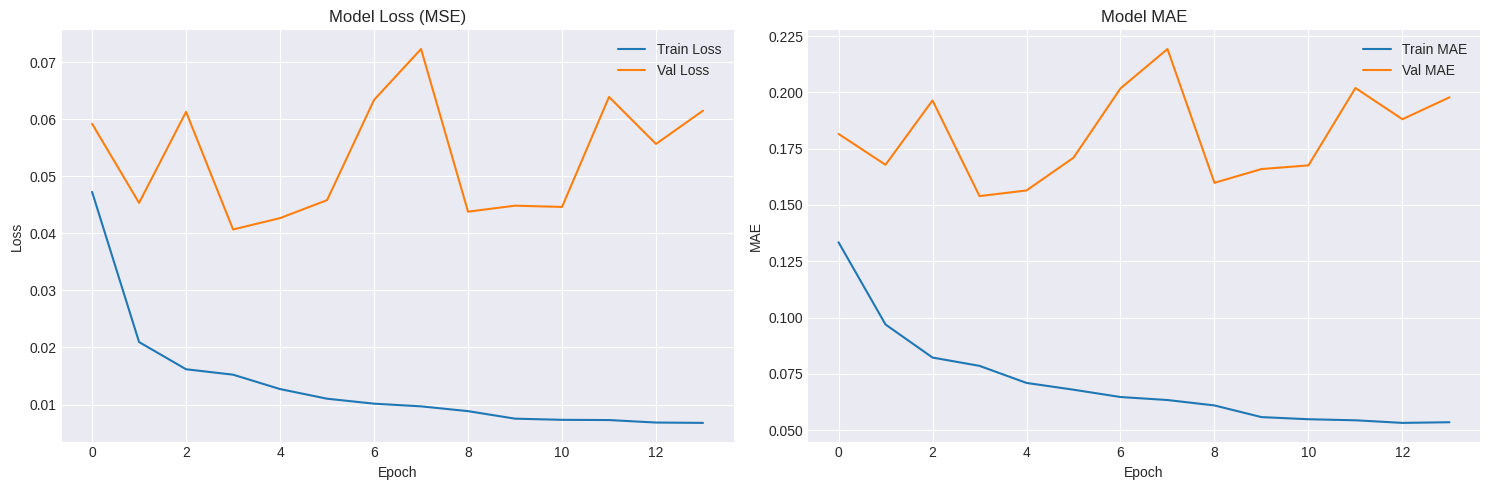

In [ ]:
# 3. Model: 1D-CNN + BiLSTM + Attention
class AttentionLayer(layers.Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)
    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1), initializer="zeros")
        super(AttentionLayer, self).build(input_shape)
    def call(self, x):
        e = tf.nn.tanh(tf.tensordot(x, self.W, axes=1) + self.b)
        a = tf.nn.softmax(e, axis=1)
        output = x * a
        return tf.reduce_sum(output, axis=1), a

def build_model(input_shape):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv1D(filters=64, kernel_size=3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
    context_vector, attention_weights = AttentionLayer(name='attention_weights')(x)
    x = layers.Dense(32, activation='relu')(context_vector)
    outputs = layers.Dense(1)(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

model = build_model((LOOKBACK, X_train.shape[2]))

# Training configuration
EPOCHS = 50
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Visualization of Training History
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss Curve
ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_title('Model Loss (MSE)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

# MAE Curve
ax2.plot(history.history['mae'], label='Train MAE')
ax2.plot(history.history['val_mae'], label='Val MAE')
ax2.set_title('Model MAE')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE')
ax2.legend()

plt.tight_layout()
plt.show()

81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step


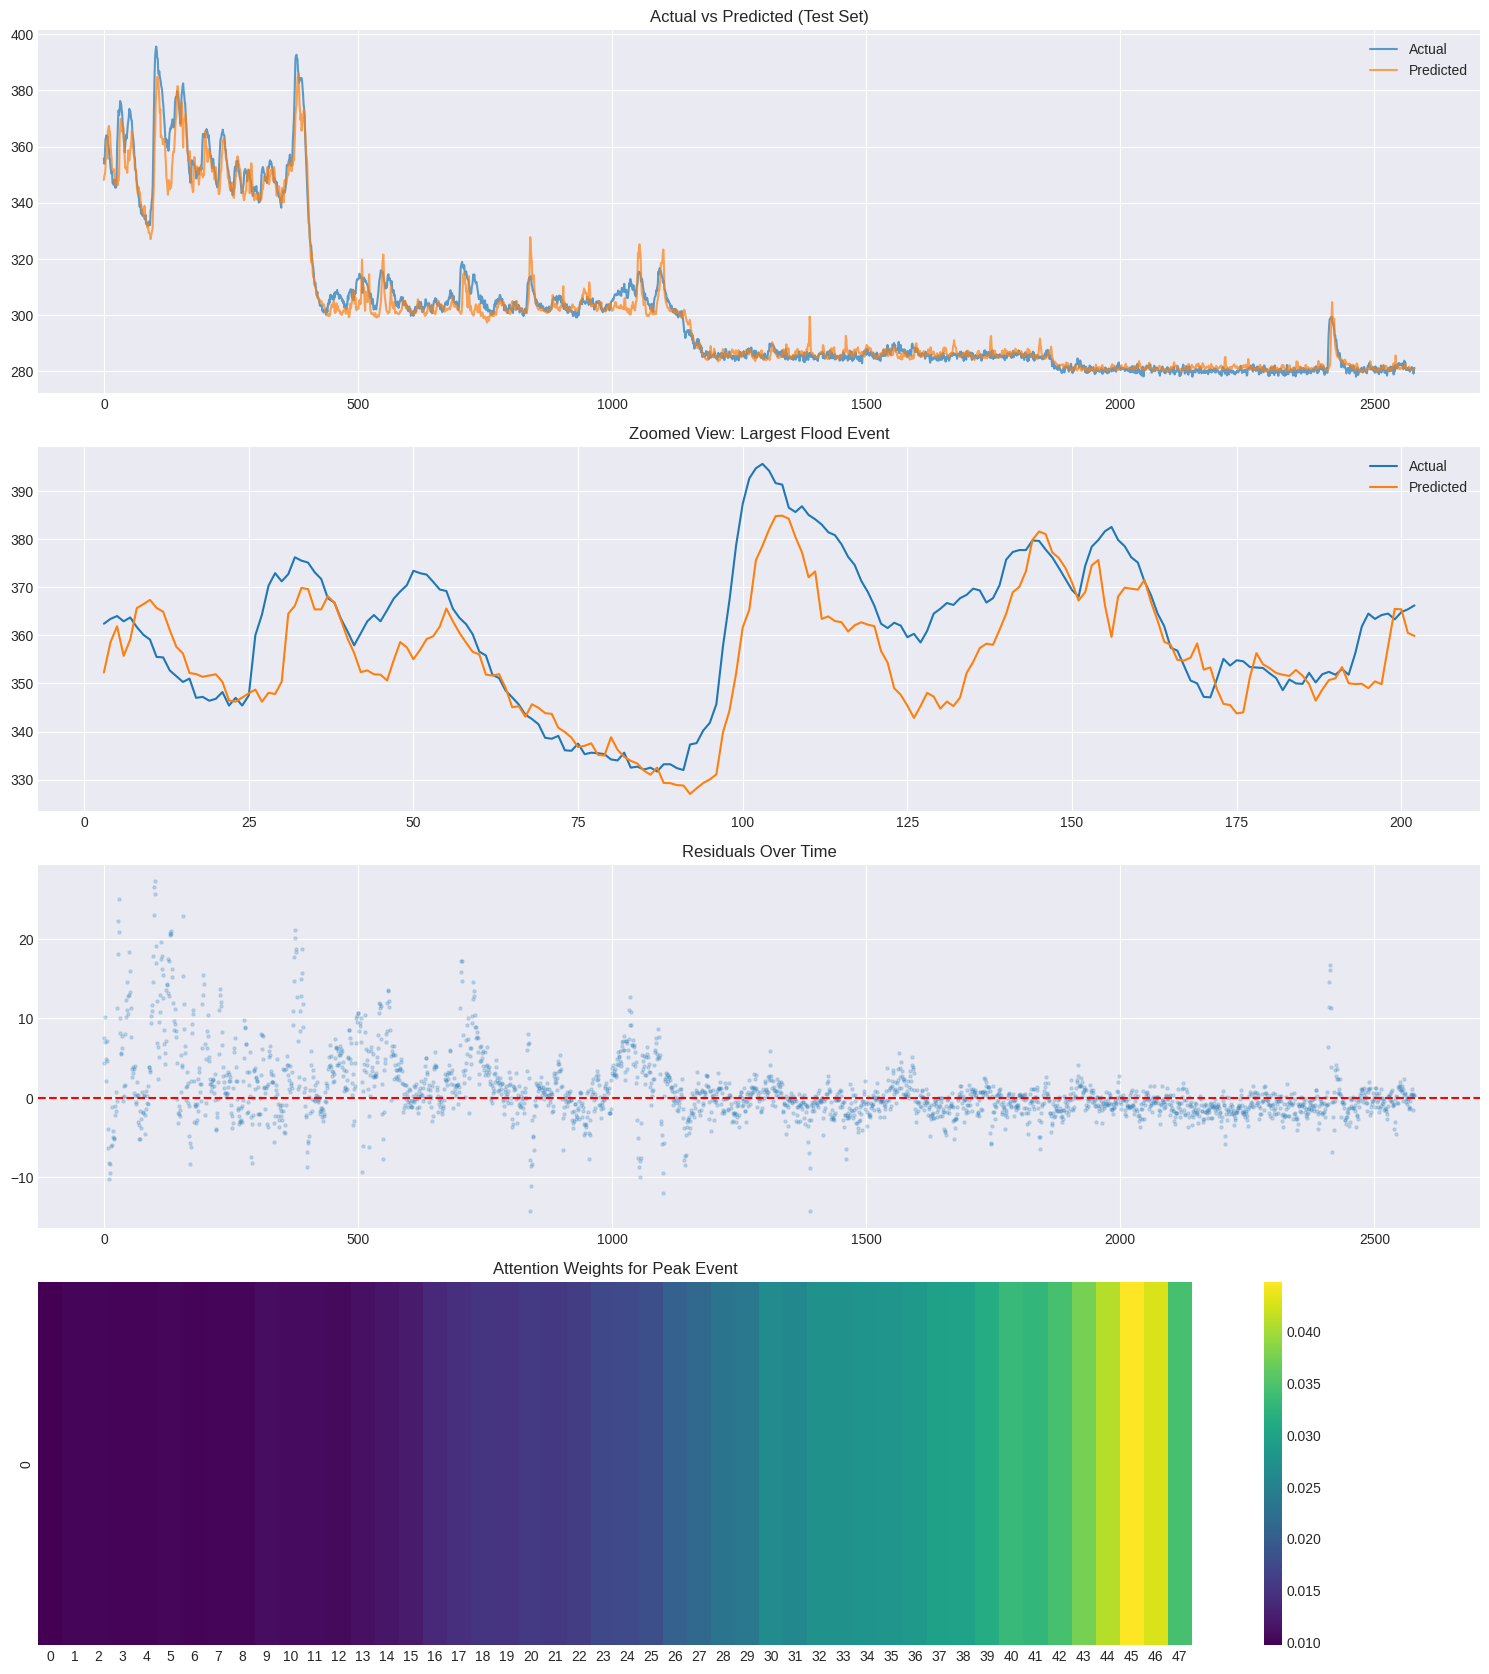

In [ ]:
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

plt.figure(figsize=(15, 25))

# Plot 1: Full Test Overlaid
plt.subplot(6, 1, 1)
plt.plot(y_true, label='Actual', alpha=0.7)
plt.plot(y_pred, label='Predicted', alpha=0.7)
plt.title('Actual vs Predicted (Test Set)')
plt.legend()

# Plot 2: Zoomed Flood Event
plt.subplot(6, 1, 2)
max_idx = np.argmax(y_true)
start, end = max(0, max_idx-100), min(len(y_true), max_idx+100)
plt.plot(range(start, end), y_true[start:end], label='Actual')
plt.plot(range(start, end), y_pred[start:end], label='Predicted')
plt.title('Zoomed View: Largest Flood Event')
plt.legend()

# Plot 3: Residuals
plt.subplot(6, 1, 3)
residuals = y_true - y_pred
plt.scatter(range(len(residuals)), residuals, alpha=0.2, s=5)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals Over Time')

# Plot 4: Attention Weights
plt.subplot(6, 1, 4)
layer_name = 'attention_weights'
attention_model = models.Model(inputs=model.input, outputs=[model.output, model.get_layer(layer_name).output[1]])
_, att_weights = attention_model.predict(X_test[max_idx:max_idx+1])
sns.heatmap(att_weights.reshape(1, -1), cmap='viridis')
plt.title('Attention Weights for Peak Event')

plt.tight_layout()
plt.savefig('evaluation_plots.png')
plt.show()

In [ ]:
# 5. Export for Next.js
!pip install tensorflowjs

# Export Model
model.save('flood_model.h5')
!tensorflowjs_converter --input_format keras flood_model.h5 tfjs_model/

# Export Config
config = {
    "LOOKBACK": LOOKBACK,
    "DANGER_THRESHOLD": DANGER_THRESHOLD,
    "features": ['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'temperature_c', 'humidity_percent', 'pressure_hpa', 'pressure_trend_3h', 'humidity_trend_3h', 'water_level_cm', 'rate_of_change_cm_per_hr']
}
with open('config.json', 'w') as f:
    json.dump(config, f)

# Export Sample Data (200 rows)
sample_data = test_df_with_dates.iloc[:200].to_dict(orient='records')
with open('sample_data.json', 'w') as f:
    json.dump(sample_data, f)

# Zip for Download
import zipfile
with zipfile.ZipFile('flood_model_export.zip', 'w') as zipf:
    zipf.write('scalers.json')
    zipf.write('config.json')
    zipf.write('sample_data.json')
    for root, dirs, files in os.walk('tfjs_model/'):
        for file in files:
            zipf.write(os.path.join(root, file))

print("Export Complete: flood_model_export.zip")

2026-07-10 07:45:02.225910: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783669502.247073    8091 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783669502.254214    8091 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783669502.270665    8091 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783669502.270710    8091 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783669502.270715    8091 computation_placer.cc:177] computation placer alr

In [ ]:
from google.colab import files
files.download('flood_model_export.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import glob
import zipfile
from google.colab import files

images = glob.glob('*.png')
if images:
    with zipfile.ZipFile('flood_plots.zip', 'w') as img_zip:
        for img in images:
            img_zip.write(img)
    print(f'Zipped: {images}')
    files.download('flood_plots.zip')
else:
    print('No images found to zip.')

Zipped: ['evaluation_plots.png', 'eda_plots.png']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 6. Next.js Integration Instructions

#### 1. Setup Dependencies
Run the following in your Next.js project directory:
```bash
npm install @tensorflow/tfjs recharts lucide-react
```

#### 2. Implementation Logic
Place your `tfjs_model/`, `scalers.json`, and `config.json` in your project's `public/model/` folder.

```javascript
import * as tf from '@tensorflow/tfjs';

/**
 * Prediction Helper
 * @param {Array} slidingWindow - Last 48 hours of sensor readings
 */
async function predictFlood(slidingWindow) {
  const model = await tf.loadLayersModel('/model/model.json');
  const config = await fetch('/model/config.json').then(res => res.json());
  const scalers = await fetch('/model/scalers.json').then(res => res.json());

  // 1. Preprocess: Cyclical Encoding & Scaling
  const processedData = slidingWindow.map(row => {
    const hSin = Math.sin(2 * Math.PI * row.hour_of_day / 24);
    const hCos = Math.cos(2 * Math.PI * row.hour_of_day / 24);
    const mSin = Math.sin(2 * Math.PI * row.month_of_year / 12);
    const mCos = Math.cos(2 * Math.PI * row.month_of_year / 12);
    
    // Scaler logic: (value - mean) / scale
    const rawVals = [hSin, hCos, mSin, mCos, row.temp, row.hum, row.press, row.pTrend, row.hTrend, row.water, row.rate];
    return rawVals.map((v, i) => (v - scalers.x_mean[i]) / scalers.x_scale[i]);
  });

  // 2. Predict
  const inputTensor = tf.tensor3d([processedData]);
  const predictionScaled = model.predict(inputTensor);
  
  // 3. Inverse Transform
  const result = predictionScaled.dataSync()[0];
  const waterLevelCm = (result * scalers.y_scale) + scalers.y_mean;

  return waterLevelCm;
}
```

#### 3. Frontend Component (Recharts)
Use a `LineChart` from `recharts` to display the `sample_data.json` historical values along with a dot for the +4h forecast.

**Note on Attention Compatibility:**
The custom `AttentionLayer` used in Keras is implemented using standard TF operations (`tanh`, `softmax`, `reduce_sum`). It converts to TF.js as a "Lambda" or custom layer. If you encounter a `Layer 'AttentionLayer' not found` error in JS, ensure you register the custom layer class in your JS code before loading the model using `tf.serialization.registerClass(AttentionLayer)`.